# 06 · Stability: L¹ contraction, total variation, front count

Notebook 05 compared front tracking with the *exact* solution. This one compares front tracking
with **itself**. Take two step data $u_0^\delta$, $v_0^\delta$ on the same state grid, run both with the
same polygonal flux $f_\delta$, and ask what can happen to their difference, to each one's total
variation, and to the number of fronts.

Since $u^\delta$ and $v^\delta$ are exact entropy solutions of $u_t+f_\delta(u)_x=0$, every statement below
marked **exact** holds for them with no $\delta$-dependent error, up to floating point and the
cluster tolerance of notebook 04.

| claim | status |
|---|---|
| $\lVert u^\delta(t)-v^\delta(t)\rVert_{L^1}$ never increases ($L^1$ contraction) | exact (Kružkov) |
| its rate of decrease is an explicit sum over fronts | exact, derived in §2 |
| $u_0^\delta\le v_0^\delta\Rightarrow u^\delta\le v^\delta$ (comparison principle) | exact |
| $\mathrm{TV}(u^\delta(t))$ never increases, and changes only at events | exact, proof in §4 |
| number of fronts $N(t)\le \mathrm{TV}(u^\delta_0)/\delta_{\min}$ | exact, proof in §5 |
| number of events grows like $1/\delta$, even for nonconvex $f$ | observed |
| no stability in $L^\infty$ or $L^2$ | exact example, §6 |

Two things this notebook is **not** about. Contraction holds between two solutions with the **same**
$f_\delta$. Two different values of $\delta$ are two different equations, and their difference is the flux
term of notebook 05. And the front count in §5 is a measure of **cost**, not of stability. It lives here
because its bound comes from the total variation.

*Reference: S. N. Kružkov, First order quasilinear equations in several independent variables,
Math. USSR-Sb. 10 (1970) 217–243. Full references at the end.*

In [1]:
# Setup: use the local checkout if present, otherwise install from GitHub.
import os, sys, subprocess, importlib, importlib.util
from pathlib import Path
REPO = "parasuramv/scalar-front-tracking"

for candidate in (Path.cwd() / "src", Path.cwd().parent / "src"):
    if (candidate / "fronttrack").is_dir():
        sys.path.insert(0, str(candidate))
        break
if importlib.util.find_spec("fronttrack") is None:
    # GIT_TERMINAL_PROMPT=0: fail fast instead of waiting for a password prompt.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           f"git+https://github.com/{REPO}.git"],
                          env={**os.environ, "GIT_TERMINAL_PROMPT": "0"})
    importlib.invalidate_caches()
for name in ("matplotlib", "ipywidgets"):
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", name])
if "google.colab" in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import fronttrack
from fronttrack import DiscreteFlux, FrontTracker, solve_riemann

# One small, fixed palette for the whole series.
C_FLUX, C_POLY, C_ENV, C_EXACT = "#9a9a94", "#2a78d6", "#eb6834", "#222222"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "lines.linewidth": 2})
print("fronttrack", fronttrack.__version__)

fronttrack 0.2.0


## 1. $L^1$ contraction

**Theorem (Kružkov, 1970).** If $u$ and $v$ are entropy solutions of $u_t+g(u)_x=0$ with a Lipschitz
flux $g$, and $u_0-v_0\in L^1$, then for $0\le s\le t$
$$
\lVert u(t)-v(t)\rVert_{L^1}\le\lVert u(s)-v(s)\rVert_{L^1}.
$$
A polygonal flux $f_\delta$ is Lipschitz, so this applies to front tracking without change.

To measure it exactly we need no quadrature: two step functions are both constant between the
merged list of their fronts, so $\int|u^\delta-v^\delta|$ is a finite sum. The test below takes random
pairs of step data (same far-field states, so the distance is finite), runs both to $t=8$, and
records the largest *increase* of the distance between consecutive observation times.

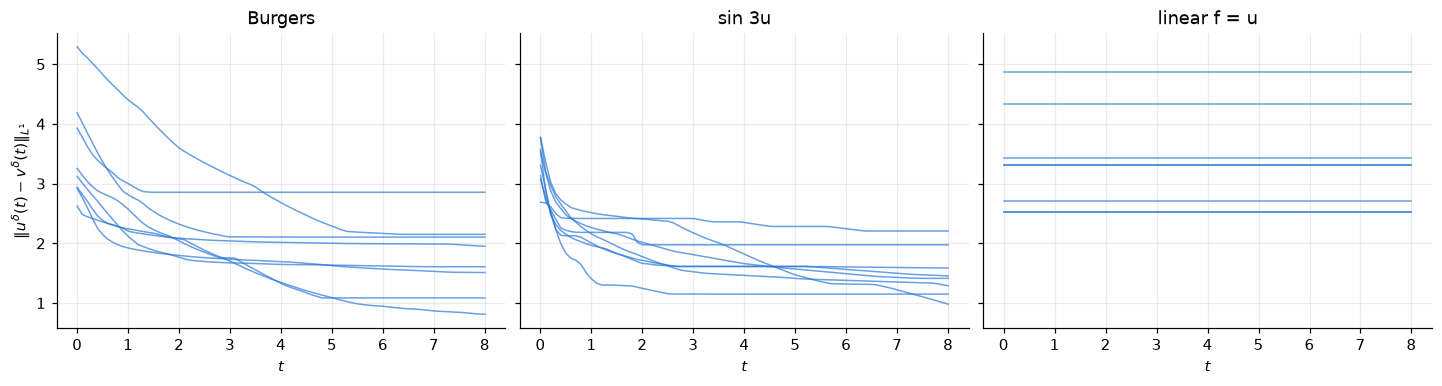

flux           pairs  largest increase  final/initial (median)
Burgers           40           8.9e-16                   0.422
sin 3u            40           2.4e-15                   0.375
linear f = u      40           4.4e-15                   1.000


In [3]:
import math
from fronttrack.interactions import next_interaction

burgers = lambda u: 0.5 * u**2
sin3 = lambda u: np.sin(3 * u)
linear = lambda u: u
FLUXES = {"Burgers": burgers, "sin 3u": sin3, "linear f = u": linear}

def fronts_x(tr):
    return np.array([f.x for f in tr.fronts])

def l1_distance(a, b):
    """Exact L1 distance of two step solutions with equal far-field states."""
    p = np.unique(np.concatenate([fronts_x(a), fronts_x(b)]))
    if p.size < 2:
        return 0.0
    mid = 0.5 * (p[1:] + p[:-1])
    return math.fsum(np.abs(a.sample(mid) - b.sample(mid)) * np.diff(p))

def random_pair(flux, rng, jumps=20):
    """Two step data on the same jump positions; interior values independent, ends equal."""
    x = np.sort(rng.uniform(-3, 3, jumps))
    va, vb = rng.uniform(-1, 1, jumps + 1), rng.uniform(-1, 1, jumps + 1)
    vb[0], vb[-1] = va[0], va[-1]
    make = lambda v: FrontTracker.from_values(flux, x, v, record_history=False)
    return make(va), make(vb)

times = np.linspace(0, 8, 81)
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True, constrained_layout=True)
lines = [f"{'flux':14s} {'pairs':>5} {'largest increase':>17} {'final/initial (median)':>23}"]
for ax, (name, f) in zip(axes, FLUXES.items()):
    flux = DiscreteFlux(f, np.linspace(-1, 1, 41))
    worst, ratios = 0.0, []
    for k in range(40):
        a, b = random_pair(flux, rng)
        d = []
        for t in times:
            a.run(t); b.run(t)
            d.append(l1_distance(a, b))
        d = np.array(d)
        worst = max(worst, np.max(np.diff(d)))
        ratios.append(d[-1] / d[0])
        if k < 8:
            ax.plot(times, d, color=C_POLY, lw=1, alpha=0.7)
    ax.set(xlabel="$t$", title=name)
    lines.append(f"{name:14s} {40:5d} {worst:17.1e} {np.median(ratios):23.3f}")
axes[0].set_ylabel(r"$\|u^\delta(t)-v^\delta(t)\|_{L^1}$")
plt.show()
print("\n".join(lines))

The largest increase is of order $10^{-15}$, which is roundoff: the distance never grows. For Burgers
and $\sin 3u$ it shrinks. For the linear flux it stays **exactly** constant, since every front moves at
speed $1$ and the whole picture just translates. Why nonlinear fluxes contract, and by how much,
has an exact answer.

## 2. Where the contraction comes from

Between two events, both solutions are step functions and all fronts move at constant speed, so
$\lVert u^\delta-v^\delta\rVert_{L^1}$ is differentiable in $t$. Consider a front of $u^\delta$ with states
$a\to b$ and speed $s=\frac{f_\delta(b)-f_\delta(a)}{b-a}$, at a point where $v^\delta$ has the constant value $c$.
(At all but finitely many times no front of $u^\delta$ sits exactly on a front of $v^\delta$.)

As the front moves, it sweeps a strip of width $s\,dt$ where $|u-v|$ changes from $|b-c|$ to $|a-c|$
(for $s>0$). Summing these rates over all fronts of both solutions gives $\frac{d}{dt}\lVert u-v\rVert_{L^1}$.
To see the sign, add the jumps of Kružkov's entropy flux $q(u,c)=\mathrm{sgn}(u-c)\,\big(f_\delta(u)-f_\delta(c)\big)$.
The function $x\mapsto q(u^\delta,v^\delta)$ is piecewise constant, jumps only at fronts, and vanishes at
$\pm\infty$, so its jumps sum to zero and adding them changes nothing. Each front then contributes
$$
E(a,b,c)=-s\,\big(|b-c|-|a-c|\big)+\big(q(b,c)-q(a,c)\big).
$$

* If $c$ is **not strictly between** $a$ and $b$, then $\mathrm{sgn}(u-c)$ is the same on both sides and
  $E=\pm\big(f_\delta(b)-f_\delta(a)-s(b-a)\big)=0$ by Rankine–Hugoniot.
* If $a<c<b$, a short computation using Rankine–Hugoniot gives
  $E=2\big(\ell(c)-f_\delta(c)\big)$, where $\ell$ is the chord from $(a,f_\delta(a))$ to $(b,f_\delta(b))$.
  The front is an edge of the lower convex envelope, so $f_\delta(c)\ge\ell(c)$ and $E\le0$. The case
  $a>c>b$ is the mirror image, with the upper concave envelope.

Together:
$$
\boxed{\;\frac{d}{dt}\lVert u^\delta-v^\delta\rVert_{L^1}
=-2\!\!\sum_{\substack{\text{fronts of } u^\delta \text{ or } v^\delta\\ \text{other solution's value } c \text{ strictly inside}}}\!\!\big|f_\delta(c)-\ell(c)\big|\;}
$$
This is Kružkov's entropy inequality with the constant $k$ chosen as the *other* solution's value, the
doubling of variables made concrete. It explains the pictures above.

* **Linear flux:** $f_\delta=\ell$ on every chord, so every term is zero and the distance is constant.
* **Nonlinear flux:** the distance drops only while a front of one solution crosses a region where the
  other solution's value lies strictly inside the front's jump, and by an amount set by how far $f_\delta$
  bulges away from that front's chord.

Since both solutions take node values, $c$ is a node, and $|f_\delta(c)-\ell(c)|$ is the gap of that node
from the chord (the same gap that `solve_riemann` tests, notebook 05 §7). Below, the formula is compared
with a one-sided finite difference of the exact distance, over a short step with no event in it.

In [4]:
import copy

def dissipation_rate(a, b):
    """-2 * sum over fronts of |f_delta(c) - chord(c)|, c = other solution's value strictly inside."""
    g, fv = a.flux.u_grid, a.flux.f_values
    total = 0.0
    for u, v in ((a, b), (b, a)):
        for fr in u.fronts:
            c = v.sample(fr.x)
            lo, hi = sorted((g[fr.iL], g[fr.iR]))
            if lo < c < hi:
                k = int(np.searchsorted(g, c))              # c is a node value
                chord = fv[fr.iL] + fr.speed * (c - g[fr.iL])
                total -= 2 * abs(fv[k] - chord)
    return total

rng = np.random.default_rng(1)
lines = [f"{'flux':8s} {'checks':>6} {'largest |FD - formula| / (1 + |formula|)':>42}"]
for name in ("Burgers", "sin 3u"):
    flux = DiscreteFlux(FLUXES[name], np.linspace(-1, 1, 41))
    mism = []
    for trial in range(30):
        a, b = random_pair(flux, rng, jumps=12)
        for t in np.linspace(0.3, 4, 12):
            a.run(t); b.run(t)
            h = 1e-7 * min(next_interaction(a.fronts)[0], next_interaction(b.fronts)[0], 1.0)
            a2, b2 = copy.deepcopy(a), copy.deepcopy(b)
            a2.run(t + h); b2.run(t + h)
            if (a2.event_count, b2.event_count) != (a.event_count, b.event_count):
                continue                                    # an event inside the step: skip
            fd = (l1_distance(a2, b2) - l1_distance(a, b)) / h
            r = dissipation_rate(a, b)
            mism.append(abs(fd - r) / (1 + abs(r)))
    lines.append(f"{name:8s} {len(mism):6d} {max(mism):42.1e}")
print("\n".join(lines))

flux     checks   largest |FD - formula| / (1 + |formula|)
Burgers     360                                    2.1e-05
sin 3u      360                                    1.1e-02


The mismatch is at the level of the finite difference's own roundoff (a difference of two $O(1)$
numbers divided by a step of about $10^{-7}$), so the identity holds.

## 3. Comparison principle

**Corollary.** If $u_0^\delta\le v_0^\delta$ everywhere, then $u^\delta(t)\le v^\delta(t)$ for all $t$.

The same computation with $|\cdot|$ replaced by the positive part $(\cdot)^+$ shows that
$\int(u^\delta-v^\delta)^+$ is nonincreasing (Kružkov's proof gives this form too). It starts at $0$, so it
stays $0$. The test raises a random set of interior values of $u_0$ by a random nonnegative amount
and tracks $\int(u^\delta-v^\delta)^+\,dx$ exactly, over the merged fronts.

Why the integral and not $\min_x(v^\delta-u^\delta)$? Where the two solutions share a front (the same
fan, from the same jump), its two copies should sit at the same point, but they reach it through
different sequences of floating-point operations. They can end up one rounding error apart, and in
that sliver of width about $10^{-16}$ one solution has crossed the front and the other has not. A
pointwise test reports a violation of size $\delta$ there. The integral weighs it by its width, as the
theorem does.

In [5]:
rng = np.random.default_rng(2)
lines = [f"{'flux':14s} {'pairs':>5} {'largest integral of (u - v)+':>29}"]
for name, f in FLUXES.items():
    flux = DiscreteFlux(f, np.linspace(-1, 1, 41))
    worst = 0.0
    for trial in range(30):
        x = np.sort(rng.uniform(-3, 3, 20))
        ua = rng.uniform(-1, 0.6, 21)
        ub = np.clip(ua + rng.uniform(0, 0.4, 21) * (rng.random(21) < 0.5), -1, 1)
        ub[0], ub[-1] = ua[0], ua[-1]
        a = FrontTracker.from_values(flux, x, ua, record_history=False)
        b = FrontTracker.from_values(flux, x, ub, record_history=False)
        for t in np.linspace(0, 8, 41):
            a.run(t); b.run(t)
            p = np.unique(np.concatenate([fronts_x(a), fronts_x(b)]))
            mid = 0.5 * (p[1:] + p[:-1])
            pos = math.fsum(np.clip(a.sample(mid) - b.sample(mid), 0, None) * np.diff(p))
            worst = max(worst, pos)
    lines.append(f"{name:14s} {30:5d} {worst:29.1e}")
print("\n".join(lines))

flux           pairs  largest integral of (u - v)+
Burgers           30                       3.3e-15
sin 3u            30                       7.2e-15
linear f = u      30                       0.0e+00


$\int(u^\delta-v^\delta)^+$ stays at roundoff level: the ordering is never violated on any set of positive
length.

## 4. Total variation

**Claim.** $\mathrm{TV}(u^\delta(t))$ is constant between events and never increases at an event.

*Proof.* Between events every front keeps its states and only moves, so the list of jumps, and with it
the total variation, is unchanged. At an event a cluster of fronts meets at one point. Let
$u_\ell, u_1,\dots,u_m, u_r$ be the states from left to right. The incoming variation is
$|u_1-u_\ell|+\dots+|u_r-u_m|\ge|u_r-u_\ell|$. The outgoing fan is the Riemann solution from $u_\ell$ to
$u_r$, and its states are **monotone** (they are the vertices of one envelope, in order), so its variation is
exactly $|u_r-u_\ell|$. $\square$

TV drops strictly at an event exactly when the incoming states are not monotone. To watch this
event by event, the cell below subclasses `FrontTracker` so that it logs the total variation before and
after every event it resolves. The plot shows $\mathrm{TV}(t)$ as a step function, and the table counts
how many events decreased it.

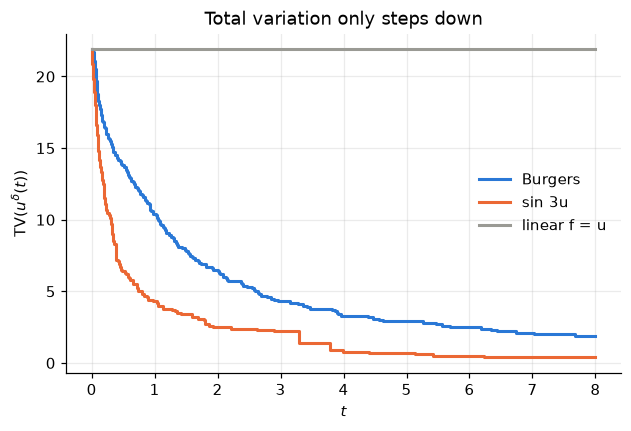

flux             TV(0)   TV(8)  events  events that lowered TV  largest increase at an event
Burgers         21.900   1.900     212                     200           0.0e+00
sin 3u          21.900   0.400     201                     177           0.0e+00
linear f = u    21.900  21.900       0                       0           0.0e+00


In [6]:
class RecordingTracker(FrontTracker):
    """FrontTracker that logs (time, TV before, TV after) at every event it resolves."""
    def _resolve_cluster(self, pair_index):
        before = self.total_variation()
        super()._resolve_cluster(pair_index)
        self.log.append((self.time, before, self.total_variation()))

def tv_history(flux, x, values, T):
    tr = RecordingTracker.from_values(flux, x, values, record_history=False)
    tr.log = []
    tv0 = tr.total_variation()
    tr.run(T)
    ts = np.array([0.0] + [e[0] for e in tr.log] + [T])
    tvs = np.array([tv0] + [e[2] for e in tr.log] + [tr.total_variation()])
    drops = sum(after < before - 1e-12 for _, before, after in tr.log)
    rises = max([after - before for _, before, after in tr.log], default=0.0)
    return ts, tvs, tr.event_count, drops, rises

rng = np.random.default_rng(3)
x, values = np.sort(rng.uniform(-3, 3, 30)), rng.uniform(-1, 1, 31)
fig, ax = plt.subplots(figsize=(6.5, 4))
lines = [f"{'flux':14s} {'TV(0)':>7} {'TV(8)':>7} {'events':>7} {'events that lowered TV':>23}"
         f" {'largest increase at an event':>29}"]
for (name, f), c in zip(FLUXES.items(), (C_POLY, C_ENV, C_FLUX)):
    ts, tvs, events, drops, rises = tv_history(DiscreteFlux(f, np.linspace(-1, 1, 41)),
                                               x, values, 8.0)
    ax.step(ts, tvs, where="post", color=c, label=name)
    lines.append(f"{name:14s} {tvs[0]:7.3f} {tvs[-1]:7.3f} {events:7d} {drops:23d}"
                 f" {max(0.0, rises):17.1e}")
ax.set(xlabel="$t$", ylabel=r"TV$(u^\delta(t))$", title="Total variation only steps down")
ax.legend(frameon=False)
plt.show()
print("\n".join(lines))

TV never increases. For the linear flux nothing ever collides (all speeds are equal), so TV is
constant. For the nonlinear fluxes most events lower TV, and a minority leave it unchanged. Those are
collisions whose incoming states were already monotone, for instance two shocks in the same direction
merging into one shock with the same total jump. A shock absorbing one step of a rarefaction always
lowers TV, since the step goes the other way.

**A caveat about the data.** The claim is about $\mathrm{TV}(u^\delta(t))\le\mathrm{TV}(u_0^\delta)$, the
variation of the *projected* data. Nearest-node rounding can make $\mathrm{TV}(u_0^\delta)$ much larger than
$\mathrm{TV}(u_0)$. A small wiggle around the midpoint between two nodes becomes a full jump of size
$\delta$ at every crossing:

In [7]:
flux = DiscreteFlux(burgers, np.linspace(-1, 1, 21))       # nodes ..., 0.0, 0.1, ...
xs = np.linspace(-1, 1, 401)
wiggle = 0.05 + 0.002 * np.sin(40 * xs)                    # stays within 0.048 .. 0.052
edges = 0.5 * (xs[1:] + xs[:-1])
tr = FrontTracker.from_values(flux, edges, wiggle, record_history=False)
print(f"TV of the sampled data:        {np.sum(np.abs(np.diff(wiggle))):.3f}")
print(f"TV after nearest-node rounding: {tr.total_variation():.3f}"
      f"   ({len(tr.fronts)} fronts from {len(edges)} jumps)")

TV of the sampled data:        0.101
TV after nearest-node rounding: 2.500   (25 fronts from 400 jumps)


Here rounding multiplies the variation by about $25$. The cell averages of notebook 05 §2 never
increase TV, which is one more reason to prefer them.

## 5. How many fronts?

**Claim.** For any flux, $N(t)\le\mathrm{TV}(u^\delta_0)/\delta_{\min}$, where $\delta_{\min}$ is the smallest
spacing of the state grid.

*Proof.* Every front joins two **different** nodes, so its jump is at least $\delta_{\min}$. Adding up the jumps,
$N(t)\,\delta_{\min}\le\mathrm{TV}(u^\delta(t))\le\mathrm{TV}(u_0^\delta)$ by §4. $\square$

The number of fronts is therefore bounded for all time, by a constant of order $1/\delta$. The number of
*events* is a different matter. For strictly convex $f$, every binary collision removes a front
(notebook 04, §6), so $E(t)\le N(0)$. For nonconvex $f$ that argument fails, and finiteness of the event
count needs a separate proof (see Holden–Risebro, Ch. 2). Here is what happens in practice, for fixed
data and a refined state grid:

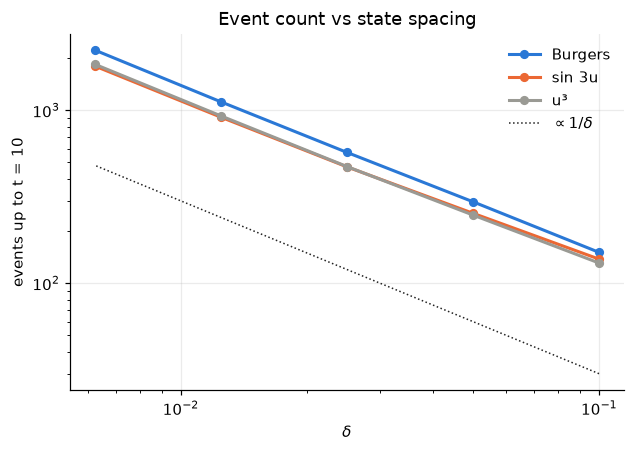

flux      nodes   N(0)  events E(10)  E/N(0)  E ratio   max N(t) * d_min / TV(0)
Burgers      21    152           151    0.99                               0.535
Burgers      41    297           296    1.00     1.96                      0.509
Burgers      81    572           571    1.00     1.93                      0.492
Burgers     161   1120          1119    1.00     1.96                      0.484
Burgers     321   2228          2227    1.00     1.99                      0.480
sin 3u       21    121           138    1.14                               0.426
sin 3u       41    218           254    1.17     1.84                      0.373
sin 3u       81    402           471    1.17     1.85                      0.346
sin 3u      161    773           912    1.18     1.94                      0.334
sin 3u      321   1522          1801    1.18     1.97                      0.328
u³           21    114           131    1.15                               0.401
u³           41    212      

In [8]:
rng = np.random.default_rng(3)
x, values = np.sort(rng.uniform(-3, 3, 40)), rng.uniform(-1, 1, 41)
node_counts = [21, 41, 81, 161, 321]
lines = [f"{'flux':8s} {'nodes':>6} {'N(0)':>6} {'events E(10)':>13} {'E/N(0)':>7} {'E ratio':>8}"
         f" {'max N(t) * d_min / TV(0)':>26}"]
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for (name, f), c in zip((("Burgers", burgers), ("sin 3u", sin3), ("u³", lambda u: u**3)),
                        (C_POLY, C_ENV, C_FLUX)):
    E, prev = [], None
    for n in node_counts:
        flux = DiscreteFlux(f, np.linspace(-1, 1, n))
        tr = FrontTracker.from_values(flux, x, values, record_history=False)
        N0, tv0, Nmax = len(tr.fronts), tr.total_variation(), len(tr.fronts)
        for t in np.linspace(0, 10, 21)[1:]:
            tr.run(t)
            Nmax = max(Nmax, len(tr.fronts))
        E.append(tr.event_count)
        ratio = "" if prev is None else f"{E[-1] / prev:8.2f}"
        prev = E[-1]
        lines.append(f"{name:8s} {n:6d} {N0:6d} {E[-1]:13d} {E[-1] / N0:7.2f} {ratio:>8}"
                     f" {Nmax * (2 / (n - 1)) / tv0:26.3f}")
    ax.loglog(2 / (np.array(node_counts) - 1), E, "o-", color=c, ms=5, label=name)
d = 2 / (np.array(node_counts) - 1)
ax.loglog(d, 3 / d, ":", color=C_EXACT, lw=1, label=r"$\propto 1/\delta$")
ax.set(xlabel=r"$\delta$", ylabel="events up to t = 10", title="Event count vs state spacing")
ax.legend(frameon=False)
plt.show()
print("\n".join(lines))

The last column is at most $1$, as the claim requires. The event count doubles each time $\delta$ is
halved, for the nonconvex fluxes as well as for Burgers, and $E/N(0)$ stays close to $1$ for Burgers and
near $1.2$ for the others. That linear growth is an observation for these data, not a theorem.

For the cost of a computation this means: about $1/\delta$ events, each found by the $O(N)$ scan of notebook
04, so about $1/\delta^2$ operations in all. A priority queue of collision times would bring this down to
about $(1/\delta)\log(1/\delta)$.

## 6. What is not stable

$L^1$ is special. The same solutions are **not** stable in $L^\infty$ or in $L^2$. Take Burgers with a single
shock $u_0=\mathbf 1_{(-1,0)}$ and the slightly higher $v_0=(1+\varepsilon)\,\mathbf 1_{(-1,0)}$. Their right edges
are shocks with speeds $\tfrac12$ and $\tfrac{1+\varepsilon}2$, so after time $t$ the two shocks are
$\varepsilon t/2$ apart, and in between the two solutions differ by about $1$. The grid below is chosen so
that $0$, $1$ and $1+\varepsilon$ are nodes and everything is exact. All three distances are computed
exactly from the fronts.

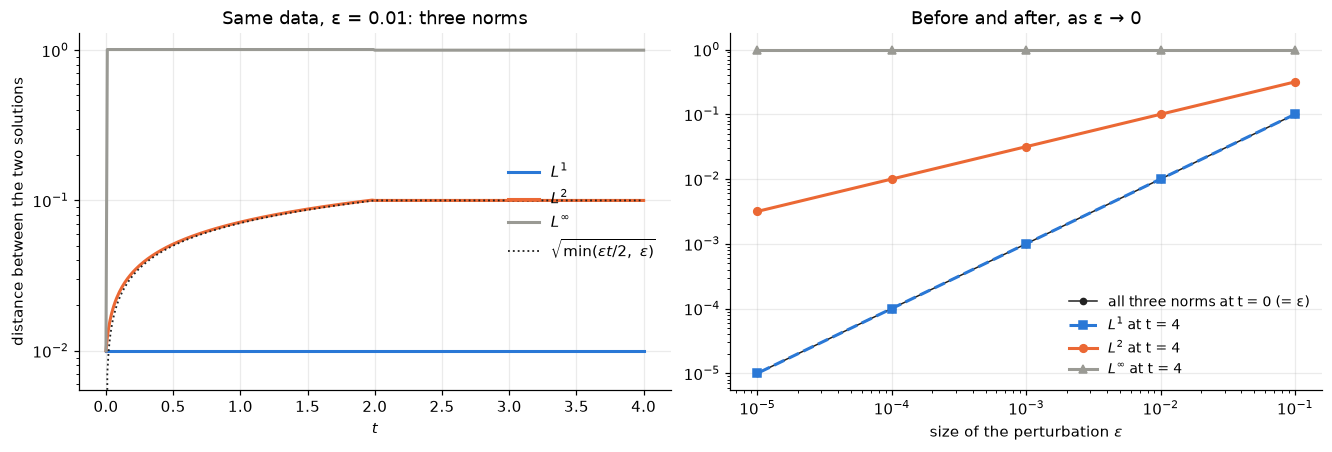

eps = 0.01
   t        L1        L2      Linf
   0    0.0100    0.0100    0.0100
 0.5    0.0100    0.0512    1.0100
   1    0.0100    0.0718    1.0100
   2    0.0100    0.1000    1.0000
   4    0.0100    0.1000    1.0000

     eps  L2 at t=4  ratio L2(4)/L2(0)
   1e-01     0.3162                3.2
   1e-02     0.1000               10.0
   1e-03     0.0316               31.6
   1e-04     0.0100              100.0
   1e-05     0.0032              316.2


In [9]:
def norms(a, b):
    """Exact L1, L2 and Linf distances of two step solutions (same far field)."""
    p = np.unique(np.concatenate([fronts_x(a), fronts_x(b)]))
    mid = 0.5 * (p[1:] + p[:-1])
    diff, w = np.abs(a.sample(mid) - b.sample(mid)), np.diff(p)
    return np.sum(diff * w), np.sqrt(np.sum(diff**2 * w)), diff.max()

def shock_pair(eps):
    """u0 = 1 on (-1,0), v0 = 1+eps on (-1,0); nodes 0, 1/2, 1, 1+eps make everything exact."""
    flux = DiscreteFlux(burgers, np.array([0.0, 0.5, 1.0, 1.0 + eps]))
    make = lambda top: FrontTracker.from_values(flux, [-1.0, 0.0], [0.0, top, 0.0],
                                                record_history=False)
    return make(1.0), make(1.0 + eps)

eps = 0.01
a, b = shock_pair(eps)
ts = np.linspace(0, 4, 401)
hist = []
for t in ts:
    a.run(t); b.run(t)
    hist.append(norms(a, b))
hist = np.array(hist)

eps_list = 10.0 ** -np.arange(1, 6)
final = []
for e in eps_list:
    a, b = shock_pair(e)
    a.run(4.0); b.run(4.0)
    final.append(norms(a, b))
final = np.array(final)

fig, (p, q) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for k, (lab, c) in enumerate(((r"$L^1$", C_POLY), (r"$L^2$", C_ENV), (r"$L^\infty$", C_FLUX))):
    p.plot(ts, hist[:, k], color=c, label=lab)
p.plot(ts, np.sqrt(np.minimum(eps * ts / 2, eps)), ":", color=C_EXACT, lw=1.2,
       label=r"$\sqrt{\min(\varepsilon t/2,\ \varepsilon)}$")
p.set(yscale="log", xlabel="$t$", ylabel="distance between the two solutions",
      title=f"Same data, ε = {eps}: three norms")
p.legend(frameon=False, loc="center right")
q.loglog(eps_list, eps_list, "o-", color=C_EXACT, ms=4, lw=1, label="all three norms at t = 0 (= ε)")
q.loglog(eps_list, final[:, 0], "s--", color=C_POLY, ms=5, label=r"$L^1$ at t = 4")
q.loglog(eps_list, final[:, 1], "o-", color=C_ENV, ms=5, label=r"$L^2$ at t = 4")
q.loglog(eps_list, final[:, 2], "^-", color=C_FLUX, ms=5, label=r"$L^\infty$ at t = 4")
q.set(xlabel=r"size of the perturbation $\varepsilon$", title="Before and after, as ε → 0")
q.legend(frameon=False, fontsize=9)
plt.show()

lines = [f"eps = {eps}", f"{'t':>4} {'L1':>9} {'L2':>9} {'Linf':>9}"]
for t in (0.0, 0.5, 1.0, 2.0, 4.0):
    i = int(np.argmin(np.abs(ts - t)))
    lines.append(f"{t:4g} " + " ".join(f"{v:9.4f}" for v in hist[i]))
lines += ["", f"{'eps':>8} {'L2 at t=4':>10} {'ratio L2(4)/L2(0)':>18}"]
for e, (l1, l2, li) in zip(eps_list, final):
    lines.append(f"{e:8.0e} {l2:10.4f} {l2 / e:18.1f}")
print("\n".join(lines))

* **$L^1$:** the distance stays exactly $\varepsilon$. It does not shrink either, and §2 says why: at every front
  of one solution, the other solution's value is an endpoint of the jump, never strictly inside it.
* **$L^\infty$:** the distance jumps from $\varepsilon$ to about $1$ as soon as $t>0$, because between the two shocks
  one solution is $0$ and the other is about $1$.
* **$L^2$:** the distance grows like $\sqrt{\varepsilon t/2}$ while the shocks separate (dotted line, left). At
  $t=2$ the faster shock has absorbed the extra step $1\to1+\varepsilon$ of its rarefaction, both shocks then
  have the same speed, and the gap freezes at $\varepsilon$. So the $L^2$ distance ends at $\sqrt\varepsilon=0.1$, ten
  times its initial value.

The right panel repeats this for $\varepsilon=10^{-1},\dots,10^{-5}$. At $t=0$ all three distances equal $\varepsilon$.
At $t=4$ the $L^1$ distance still equals $\varepsilon$ (its markers sit on the black line), the $L^\infty$ distance
is about $1$ whatever $\varepsilon$ is, and the $L^2$ distance is $\sqrt\varepsilon$: slope $\tfrac12$ instead of $1$. The
amplification factor $L^2(4)/L^2(0)=\varepsilon^{-1/2}$ is **unbounded** as $\varepsilon\to0$, so no inequality
$\lVert u(t)-v(t)\rVert_{L^2}\le C\,\lVert u_0-v_0\rVert_{L^2}$ can hold, for any constant $C$. The data-to-solution
map is still continuous in $L^2$ here, but only Hölder with exponent $\tfrac12$.

Shocks are the reason: a small change of the data moves a jump, and in $L^p$ with $p>1$ a moved jump
costs far more than the change that moved it.

## 7. Try it yourself

Two random step data with the same far field, any flux. The left panel shows the $L^1$ distance together
with the rate formula of §2 integrated in time (a Riemann sum with step $0.005$; the rate is piecewise
constant, so the two curves should nearly coincide). The right panel shows both total variations. The sliders work only
in Jupyter or Colab.

Static preview at the default settings. Run this cell in Jupyter or Colab to get the sliders.


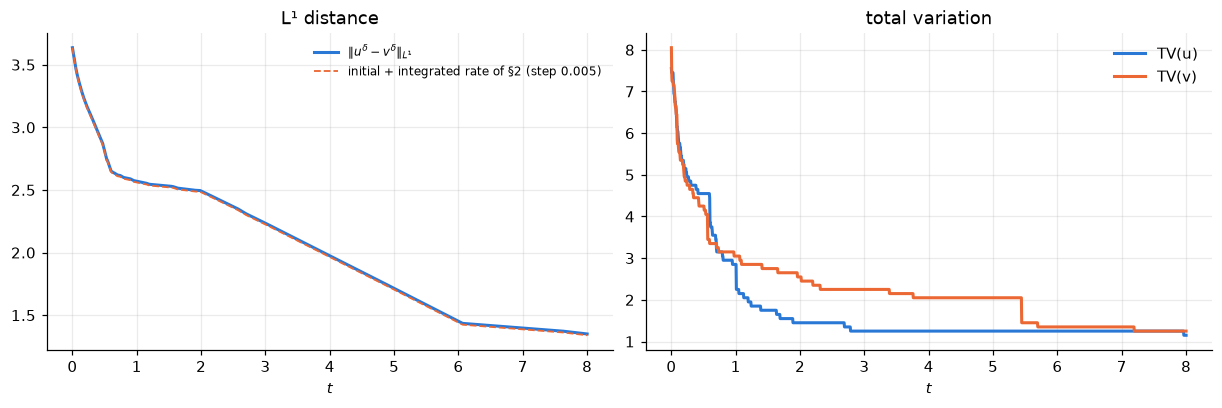

In [10]:
import ipywidgets as widgets
controls = dict(
    name=widgets.Dropdown(options=list(FLUXES) + ["u³", "traffic u(1-u)"], value="sin 3u",
                          description="flux"),
    nodes=widgets.IntSlider(value=41, min=5, max=161, step=4, description="nodes"),
    jumps=widgets.IntSlider(value=15, min=2, max=40, description="jumps"),
    seed=widgets.IntSlider(value=0, min=0, max=20, description="seed"))
more = {"u³": lambda u: u**3, "traffic u(1-u)": lambda u: u * (1 - u)}
def show(name, nodes, jumps, seed):
    flux = DiscreteFlux({**FLUXES, **more}[name], np.linspace(-1, 1, nodes))
    a, b = random_pair(flux, np.random.default_rng(seed), jumps)
    ts = np.linspace(0, 8, 1601)   # fine steps: the rate is piecewise constant
    d, tva, tvb, integ = [], [], [], [0.0]
    for k, t in enumerate(ts):
        if k:
            integ.append(integ[-1] + dissipation_rate(a, b) * (t - ts[k - 1]))
        a.run(t); b.run(t)
        d.append(l1_distance(a, b)); tva.append(a.total_variation()); tvb.append(b.total_variation())
    fig, (p, q) = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
    p.plot(ts, d, color=C_POLY, label=r"$\|u^\delta-v^\delta\|_{L^1}$")
    p.plot(ts, d[0] + np.array(integ), "--", color=C_ENV, lw=1.2,
           label="initial + integrated rate of §2 (step 0.005)")
    p.set(xlabel="$t$", title="L¹ distance")
    p.legend(frameon=False, fontsize=8)
    q.plot(ts, tva, color=C_POLY, label="TV(u)"); q.plot(ts, tvb, color=C_ENV, label="TV(v)")
    q.set(xlabel="$t$", title="total variation")
    q.legend(frameon=False)
    plt.show()
display(widgets.HBox(list(controls.values()), layout=widgets.Layout(flex_flow="row wrap")),
        widgets.interactive_output(show, controls))

## References

* S. N. Kružkov, First order quasilinear equations in several independent variables,
  *Math. USSR-Sb.* **10** (1970) 217–243.
* C. M. Dafermos, Polygonal approximations of solutions of the initial value problem for a
  conservation law, *J. Math. Anal. Appl.* **38**(1) (1972) 33–41.
* H. Holden, N. H. Risebro, *Front Tracking for Hyperbolic Conservation Laws*, 2nd ed.,
  Springer (2015), Ch. 2.

---
This is the last notebook of the series. **03** built the Riemann solver, **04** the event loop, **05**
measured how close the result is to the true solution, and **06** how the method behaves as a
dynamical system in its own right.